## Feature engineering v1 (more features => worse resutls)

In [6]:
import pandas as pd
import numpy as np
import glob

def load_dataset(folder):
    all_files = glob.glob(f"{folder}/**/*.csv", recursive=True)
    samples = []

    print(f"Found {len(all_files)} files in '{folder}'")

    for i, filepath in enumerate(all_files, start=1):

        if i % 500 == 0 or i == 1:
            print(f"[{folder}] Processed {i}/{len(all_files)} files")

        df = pd.read_csv(filepath)

        file_id = df['file_id'].iloc[0]
        label = df['label'].iloc[0] if 'label' in df.columns else None

        features = {}

        for col in ['mean_x', 'mean_y', 'mean_z', 'std_x', 'std_y', 'std_z']:
            features[f'{col}_mean'] = df[col].mean()
            features[f'{col}_std'] = df[col].std()
            features[f'{col}_min'] = df[col].min()
            features[f'{col}_max'] = df[col].max()
            features[f'{col}_median'] = df[col].median()

            features[f'{col}_range'] = df[col].max() - df[col].min()
            features[f'{col}_q25'] = df[col].quantile(0.25)
            features[f'{col}_q75'] = df[col].quantile(0.75)

            # new features
            features[f'{col}_skew'] = df[col].skew()
            features[f'{col}_kurtosis'] = df[col].kurtosis()
            features[f'{col}_start'] = df[col].iloc[0]
            features[f'{col}_end'] = df[col].iloc[-1]
            features[f'{col}_slope'] = df[col].iloc[-1] - df[col].iloc[0]

        mag = np.sqrt(
            df['mean_x']**2 +
            df['mean_y']**2 +
            df['mean_z']**2
        )

        features['mag_mean'] = mag.mean()
        features['mag_std'] = mag.std()
        features['mag_min'] = mag.min()
        features['mag_max'] = mag.max()
        features['mag_range'] = mag.max() - mag.min()

        features['file_id'] = file_id
        features['label'] = label

        samples.append(features)

    print(f"Finished loading '{folder}'")

    return pd.DataFrame(samples)


train_df = load_dataset("train")
test_df = load_dataset("test")

print(f"Train: {train_df.shape}")
print(f"Test:  {test_df.shape}")

Found 11020 files in 'train'
[train] Processed 1/11020 files
[train] Processed 500/11020 files
[train] Processed 1000/11020 files
[train] Processed 1500/11020 files
[train] Processed 2000/11020 files
[train] Processed 2500/11020 files
[train] Processed 3000/11020 files
[train] Processed 3500/11020 files
[train] Processed 4000/11020 files
[train] Processed 4500/11020 files
[train] Processed 5000/11020 files
[train] Processed 5500/11020 files
[train] Processed 6000/11020 files
[train] Processed 6500/11020 files
[train] Processed 7000/11020 files
[train] Processed 7500/11020 files
[train] Processed 8000/11020 files
[train] Processed 8500/11020 files
[train] Processed 9000/11020 files
[train] Processed 9500/11020 files
[train] Processed 10000/11020 files
[train] Processed 10500/11020 files
[train] Processed 11000/11020 files
Finished loading 'train'
Found 6849 files in 'test'
[test] Processed 1/6849 files
[test] Processed 500/6849 files
[test] Processed 1000/6849 files
[test] Processed 150

# Feature engineering v2 (less features => better results)

In [ ]:
import pandas as pd
import numpy as np
import glob

def load_dataset(folder):
    all_files = glob.glob(f"{folder}/**/*.csv", recursive=True)
    samples = []

    print(f"Found {len(all_files)} files in '{folder}'")

    for i, filepath in enumerate(all_files, start=1):

        if i % 500 == 0 or i == 1:
            print(f"[{folder}] Processed {i}/{len(all_files)} files")

        df = pd.read_csv(filepath)

        file_id = df['file_id'].iloc[0]
        label = df['label'].iloc[0] if 'label' in df.columns else None

        features = {}

        for col in ['mean_x', 'mean_y', 'mean_z', 'std_x', 'std_y', 'std_z']:
            features[f'{col}_mean'] = df[col].mean()
            features[f'{col}_std'] = df[col].std()
            features[f'{col}_min'] = df[col].min()
            features[f'{col}_max'] = df[col].max()
            features[f'{col}_median'] = df[col].median()

            features[f'{col}_range'] = df[col].max() - df[col].min()
            features[f'{col}_q25'] = df[col].quantile(0.25)
            features[f'{col}_q75'] = df[col].quantile(0.75)

        mag = np.sqrt(
            df['mean_x']**2 +
            df['mean_y']**2 +
            df['mean_z']**2
        )

        features['mag_mean'] = mag.mean()
        features['mag_std'] = mag.std()
        features['mag_min'] = mag.min()
        features['mag_max'] = mag.max()

        features['file_id'] = file_id
        features['label'] = label

        samples.append(features)

    print(f"Finished loading '{folder}'")

    return pd.DataFrame(samples)


train_df = load_dataset("train")
test_df = load_dataset("test")

print(f"Train: {train_df.shape}")
print(f"Test:  {test_df.shape}")

## Preparation of X,Y and normalization

In [7]:
feature_cols = [c for c in train_df.columns
                if c not in ['file_id', 'label']]

X_train = train_df[feature_cols].values
y_train = train_df['label'].values
X_test = test_df[feature_cols].values

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (11020, 83)
X_test shape:  (6849, 83)


## XGBoost (small test)

In [4]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss'
)

scores = cross_val_score(xgb, X_train, y_train,
                         cv=5, scoring='f1_macro')
print(f"XGBoost F1-macro: {scores.mean():.4f}")

XGBoost F1-macro: 0.6915


# XGBoost (testing with more configuration)

In [8]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

print(f"Macro F1: {scores.mean():.4f}")
print(f"Std:      {scores.std():.4f}")

Macro F1: 0.7354
Std:      0.0133


# XGBoost (what feature model use the most?)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4643
           1       1.00      1.00      1.00      4695
           2       1.00      1.00      1.00       358
           3       1.00      1.00      1.00       656
           4       1.00      1.00      1.00       142
           5       1.00      1.00      1.00       526

    accuracy                           1.00     11020
   macro avg       1.00      1.00      1.00     11020
weighted avg       1.00      1.00      1.00     11020


CONFUSION MATRIX
[[4643    0    0    0    0    0]
 [   0 4695    0    0    0    0]
 [   0    0  358    0    0    0]
 [   0    0    0  656    0    0]
 [   0    0    0    0  142    0]
 [   0    0    0    0    0  526]]


<Figure size 800x800 with 0 Axes>

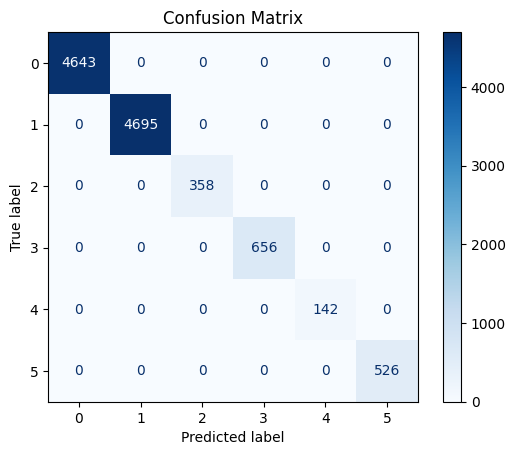


TOP 20 MOST IMPORTANT FEATURES
          Feature  Importance
46      std_x_q75    0.240499
72      std_z_q75    0.086934
52     std_y_mean    0.056903
59      std_y_q75    0.055470
58      std_y_q25    0.052906
56   std_y_median    0.032435
71      std_z_q25    0.020966
43   std_x_median    0.015599
53      std_y_std    0.015582
69   std_z_median    0.015292
54      std_y_min    0.015233
45      std_x_q25    0.012846
18   mean_y_range    0.011899
0     mean_x_mean    0.011849
79        mag_std    0.011766
30  mean_z_median    0.009428
14     mean_y_std    0.009402
33     mean_z_q75    0.008111
27     mean_z_std    0.007961
67      std_z_min    0.007874

CLASS 4 ANALYSIS
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
Support:   142.0


In [9]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd

# Train model
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

# Predictions
y_pred = xgb.predict(X_train)

# Classification report
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_train, y_pred))

# Confusion matrix
cm = confusion_matrix(y_train, y_pred)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)
print(cm)

# Visual confusion matrix
plt.figure(figsize=(8, 8))
ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Feature importance
importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 MOST IMPORTANT FEATURES")
print("=" * 60)
print(importance.head(20))

# Specifically inspect class 4
report = classification_report(
    y_train,
    y_pred,
    output_dict=True
)

print("\n" + "=" * 60)
print("CLASS 4 ANALYSIS")
print("=" * 60)

print(f"Precision: {report['4']['precision']:.4f}")
print(f"Recall:    {report['4']['recall']:.4f}")
print(f"F1-score:  {report['4']['f1-score']:.4f}")
print(f"Support:   {report['4']['support']}")

# Which class has the biggest problem?

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

xgb.fit(X_tr, y_tr)

y_pred = xgb.predict(X_val)

print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       929
           1       0.87      0.93      0.90       939
           2       0.70      0.10      0.17        72
           3       0.73      0.77      0.75       131
           4       0.86      0.89      0.88        28
           5       0.83      0.66      0.73       105

    accuracy                           0.90      2204
   macro avg       0.82      0.72      0.73      2204
weighted avg       0.89      0.90      0.88      2204

[[900  28   0   1   0   0]
 [ 43 871   0  16   0   9]
 [  1  50   7  10   2   2]
 [  0  22   3 101   2   3]
 [  0   0   0   3  25   0]
 [  0  28   0   8   0  69]]


# Adding weights

In [11]:
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

# Testing new weights

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4643
           1       1.00      1.00      1.00      4695
           2       1.00      1.00      1.00       358
           3       1.00      1.00      1.00       656
           4       1.00      1.00      1.00       142
           5       1.00      1.00      1.00       526

    accuracy                           1.00     11020
   macro avg       1.00      1.00      1.00     11020
weighted avg       1.00      1.00      1.00     11020


CONFUSION MATRIX
[[4643    0    0    0    0    0]
 [   0 4695    0    0    0    0]
 [   0    0  358    0    0    0]
 [   0    0    0  656    0    0]
 [   0    0    0    0  142    0]
 [   0    0    0    0    0  526]]


<Figure size 800x800 with 0 Axes>

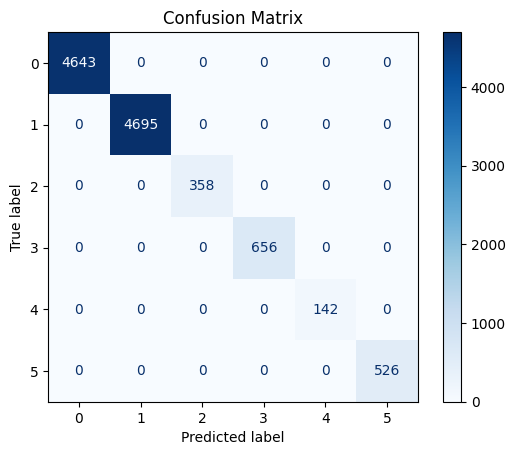


TOP 20 MOST IMPORTANT FEATURES
          Feature  Importance
46      std_x_q75    0.133696
58      std_y_q25    0.060263
52     std_y_mean    0.055794
56   std_y_median    0.055597
79        mag_std    0.047489
72      std_z_q75    0.043811
59      std_y_q75    0.033238
45      std_x_q25    0.023548
71      std_z_q25    0.023488
69   std_z_median    0.021622
18   mean_y_range    0.020642
54      std_y_min    0.020022
14     mean_y_std    0.019588
30  mean_z_median    0.017907
43   std_x_median    0.017086
67      std_z_min    0.011725
33     mean_z_q75    0.010230
40      std_x_std    0.009776
15     mean_y_min    0.009440
19     mean_y_q25    0.009412

CLASS 4 ANALYSIS
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
Support:   142.0


In [13]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd

# Train model
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)
# Predictions
y_pred = xgb.predict(X_train)

# Classification report
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_train, y_pred))

# Confusion matrix
cm = confusion_matrix(y_train, y_pred)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)
print(cm)

# Visual confusion matrix
plt.figure(figsize=(8, 8))
ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Feature importance
importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 MOST IMPORTANT FEATURES")
print("=" * 60)
print(importance.head(20))

# Specifically inspect class 4
report = classification_report(
    y_train,
    y_pred,
    output_dict=True
)

print("\n" + "=" * 60)
print("CLASS 4 ANALYSIS")
print("=" * 60)

print(f"Precision: {report['4']['precision']:.4f}")
print(f"Recall:    {report['4']['recall']:.4f}")
print(f"F1-score:  {report['4']['f1-score']:.4f}")
print(f"Support:   {report['4']['support']}")

# Validation test

VALIDATION CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       929
           1       0.89      0.92      0.90       939
           2       0.57      0.17      0.26        72
           3       0.67      0.78      0.72       131
           4       0.89      0.89      0.89        28
           5       0.73      0.66      0.69       105

    accuracy                           0.89      2204
   macro avg       0.79      0.73      0.74      2204
weighted avg       0.89      0.89      0.89      2204

VALIDATION CONFUSION MATRIX
[[900  27   0   1   0   1]
 [ 39 860   4  23   0  13]
 [  1  38  12  13   1   7]
 [  1  18   4 102   2   4]
 [  0   0   0   3  25   0]
 [  0  25   1  10   0  69]]


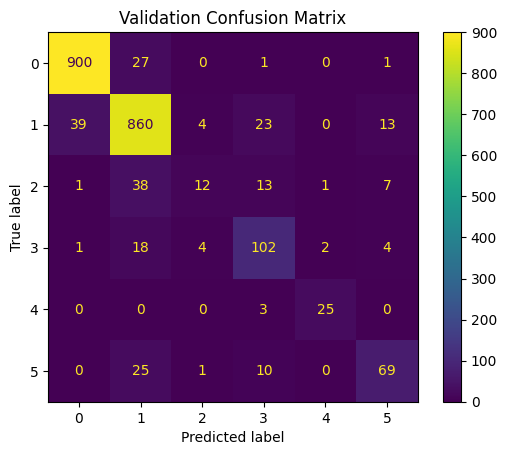

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# 1) Split na train a validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

# 2) Váhy jen pro trénovací část
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_tr
)

# 3) XGBoost model
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

# 4) Trénink s vahami
xgb.fit(
    X_tr,
    y_tr,
    sample_weight=sample_weights
)

# 5) Predikce na validačních datech
y_pred = xgb.predict(X_val)

# 6) Report
print("VALIDATION CLASSIFICATION REPORT")
print(classification_report(y_val, y_pred))

# 7) Confusion matrix
cm = confusion_matrix(y_val, y_pred)
print("VALIDATION CONFUSION MATRIX")
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Validation Confusion Matrix")
plt.show()

# Differnece between 1 and 2 class

In [2]:
import pandas as pd
import numpy as np
import glob

# =========================
# 1) DATA LOADING + FEATURES
# =========================

def load_dataset(folder):
    all_files = glob.glob(f"{folder}/**/*.csv", recursive=True)
    samples = []

    print(f"Found {len(all_files)} files in '{folder}'")

    for i, filepath in enumerate(all_files, start=1):

        if i % 500 == 0 or i == 1:
            print(f"[{folder}] Processed {i}/{len(all_files)} files")

        df = pd.read_csv(filepath)

        file_id = df['file_id'].iloc[0]
        label = df['label'].iloc[0] if 'label' in df.columns else None

        features = {}

        for col in ['mean_x', 'mean_y', 'mean_z', 'std_x', 'std_y', 'std_z']:
            features[f'{col}_mean'] = df[col].mean()
            features[f'{col}_std'] = df[col].std()
            features[f'{col}_min'] = df[col].min()
            features[f'{col}_max'] = df[col].max()
            features[f'{col}_median'] = df[col].median()

            features[f'{col}_range'] = df[col].max() - df[col].min()
            features[f'{col}_q25'] = df[col].quantile(0.25)
            features[f'{col}_q75'] = df[col].quantile(0.75)

        mag = np.sqrt(
            df['mean_x']**2 +
            df['mean_y']**2 +
            df['mean_z']**2
        )

        features['mag_mean'] = mag.mean()
        features['mag_std'] = mag.std()
        features['mag_min'] = mag.min()
        features['mag_max'] = mag.max()

        features['file_id'] = file_id
        features['label'] = label

        samples.append(features)

    print(f"Finished loading '{folder}'")

    return pd.DataFrame(samples)


train_df = load_dataset("train")
test_df = load_dataset("test")

print(f"Train: {train_df.shape}")
print(f"Test:  {test_df.shape}")


# =========================
# 2) PREPARE X AND y
# =========================

feature_cols = [c for c in train_df.columns
                if c not in ['file_id', 'label']]

X_train = train_df[feature_cols].values
y_train = train_df['label'].values
X_test = test_df[feature_cols].values

print(f"Number of features: {len(feature_cols)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")


# =========================
# 3) CHECK CLASS DISTRIBUTION
# =========================

print("\nClass distribution:")
print(train_df['label'].value_counts().sort_index())


# =========================
# 4) COMPARE CLASS 1 VS CLASS 2
# =========================

class_means = train_df.groupby("label")[feature_cols].mean()

comparison_1_2 = pd.DataFrame({
    "class_1_mean": class_means.loc[1],
    "class_2_mean": class_means.loc[2],
})

comparison_1_2["absolute_difference"] = (
    comparison_1_2["class_1_mean"] - comparison_1_2["class_2_mean"]
).abs()

comparison_1_2 = comparison_1_2.sort_values(
    by="absolute_difference",
    ascending=False
)

print("\nTop features separating class 1 and class 2:")
print(comparison_1_2.head(20))

Found 11020 files in 'train'
[train] Processed 1/11020 files
[train] Processed 500/11020 files
[train] Processed 1000/11020 files
[train] Processed 1500/11020 files
[train] Processed 2000/11020 files
[train] Processed 2500/11020 files
[train] Processed 3000/11020 files
[train] Processed 3500/11020 files
[train] Processed 4000/11020 files
[train] Processed 4500/11020 files
[train] Processed 5000/11020 files
[train] Processed 5500/11020 files
[train] Processed 6000/11020 files
[train] Processed 6500/11020 files
[train] Processed 7000/11020 files
[train] Processed 7500/11020 files
[train] Processed 8000/11020 files
[train] Processed 8500/11020 files
[train] Processed 9000/11020 files
[train] Processed 9500/11020 files
[train] Processed 10000/11020 files
[train] Processed 10500/11020 files
[train] Processed 11000/11020 files
Finished loading 'train'
Found 6849 files in 'test'
[test] Processed 1/6849 files
[test] Processed 500/6849 files
[test] Processed 1000/6849 files
[test] Processed 150